In [8]:
import kagglehub
import os
import shutil
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Step 1.1: Download the dataset
path = kagglehub.dataset_download("kritikseth/fruit-and-vegetable-image-recognition")
print("Dataset downloaded to:", path)

# Step 1.2: Define categories based on the case study instructions
fruits_list = ['banana', 'apple', 'pear', 'grapes', 'orange', 'kiwi', 'watermelon', 'pomegranate', 'pineapple', 'mango']
vegetables_list = ['cucumber', 'carrot', 'capsicum', 'onion', 'potato', 'lemon', 'tomato', 'raddish', 'beetroot', 'cabbage',
                   'lettuce', 'spinach', 'soy bean', 'cauliflower', 'bell pepper', 'chilli pepper', 'turnip', 'corn',
                   'sweetcorn', 'sweetpotato', 'paprika', 'jalepeno', 'ginger', 'garlic', 'peas', 'eggplant']

# Step 1.3: Create a new directory structure for Binary Classification
base_dir = 'binary_classification_data'
for split in ['train', 'validation', 'test']:
    for category in ['Fruits', 'Vegetables']:
        os.makedirs(os.path.join(base_dir, split, category), exist_ok=True)

# Step 1.4: Reorganize files into the two main categories
def reorganize_data(split):
    src_path = os.path.join(path, split)
    for folder in os.listdir(src_path):
        folder_path = os.path.join(src_path, folder)
        if os.path.isdir(folder_path):
            # Map specific folder name to 'Fruits' or 'Vegetables'
            target_cat = 'Fruits' if folder.lower() in fruits_list else 'Vegetables'
            dest_path = os.path.join(base_dir, split, target_cat)
            for img in os.listdir(folder_path):
                shutil.copy(os.path.join(folder_path, img), os.path.join(dest_path, f"{folder}_{img}"))

for s in ['train', 'validation', 'test']:
    reorganize_data(s)
print("Data reorganization complete.")


Using Colab cache for faster access to the 'fruit-and-vegetable-image-recognition' dataset.
Dataset downloaded to: /kaggle/input/fruit-and-vegetable-image-recognition
Data reorganization complete.


In [9]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    'binary_classification_data/train',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    'binary_classification_data/validation',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# Optimization for performance
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)


Found 3115 files belonging to 2 classes.
Found 351 files belonging to 2 classes.


In [10]:
# Load pre-trained MobileNetV2
base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model = models.Sequential([
    layers.Rescaling(1./255), # Normalize pixel values to [0,1]
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [11]:
history = model.fit(train_ds, validation_data=val_ds, epochs=5)


Epoch 1/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.8013 - loss: 0.4179 - val_accuracy: 0.9202 - val_loss: 0.2489
Epoch 2/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.9091 - loss: 0.2434 - val_accuracy: 0.9373 - val_loss: 0.1822
Epoch 3/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.9265 - loss: 0.1960 - val_accuracy: 0.9459 - val_loss: 0.1550
Epoch 4/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9348 - loss: 0.1688 - val_accuracy: 0.9516 - val_loss: 0.1403
Epoch 5/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.9461 - loss: 0.1507 - val_accuracy: 0.9573 - val_loss: 0.1258


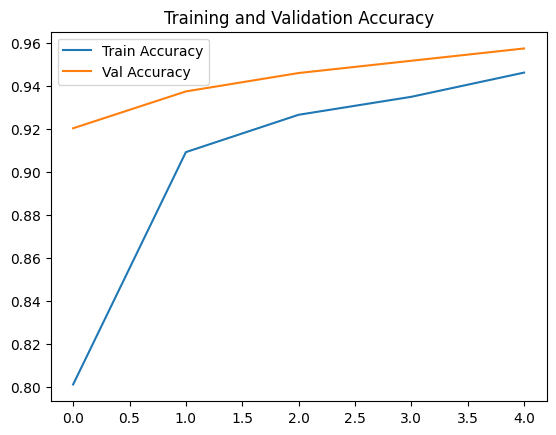

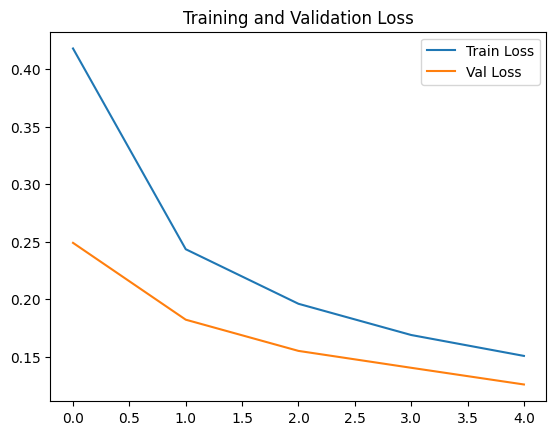

In [12]:
# Accuracy Plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

# Loss Plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()
